In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_palette('husl')
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA, FastICA, KernelPCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
dataset = pd.read_csv('/content/drive/MyDrive/AI/MushroomDataset/secondary_data.csv', sep=';')

In [4]:
dataset.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

берём только числовые столбцы и 2 категориальных, остальное выкидываем

In [6]:
cols_for_clusters = ['cap-diameter', 'stem-height', 'stem-width', 'cap-color', 'gill-color']

In [7]:
df = dataset[cols_for_clusters].copy()

кодируем катигориальные признаки

In [8]:
for col in ['cap-color', 'gill-color']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].fillna('missing'))

кодируем цп

In [9]:
vals = dataset["class"].unique()

кодируем целевую переменную

In [10]:
X = df
y = dataset["class"].replace(vals, [0, 1])
yvals = dataset["class"]

Линейные методы уменьшения размерности

Метод главных компонентов (Principal Component Analysis, PCA)

In [11]:
pca = PCA(n_components=2)
X_new = pca.fit(X).transform(X)

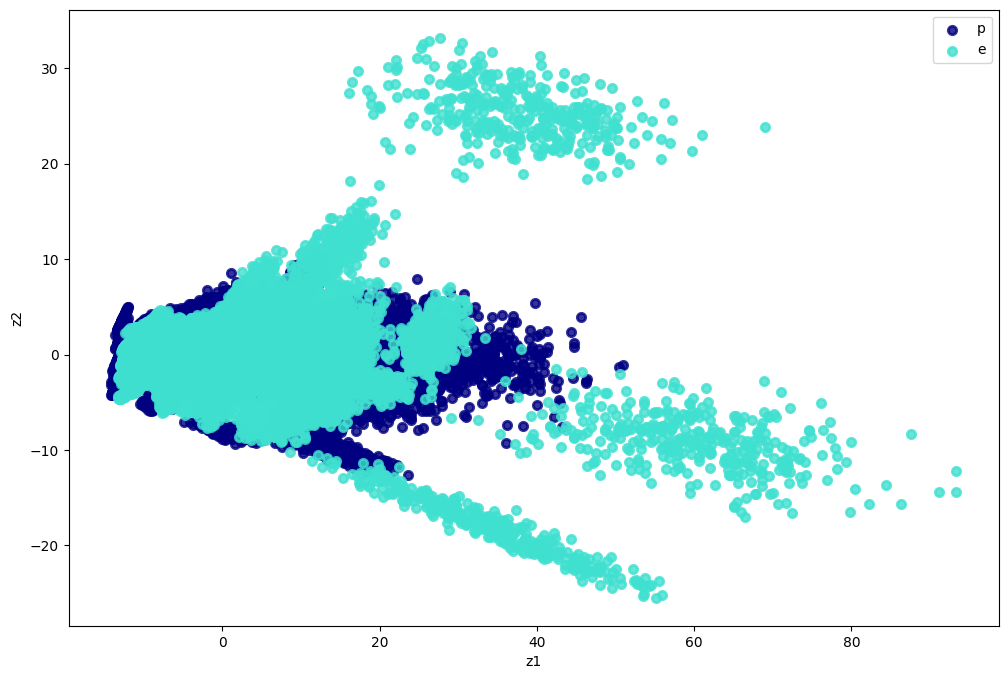

In [12]:
plt.figure(figsize=(12,8))
colors = ['navy', 'turquoise']
lw = 2
for color, i, target_name in zip(colors, [0, 1], vals):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=target_name
    )
plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

In [13]:
pca.explained_variance_ratio_

array([0.7423476, 0.0895631])

Независисый анализ компонентов (Independent Component Analysis, ICA)

In [14]:
fast_ica = FastICA(n_components=2)
X_new = fast_ica.fit_transform(X)

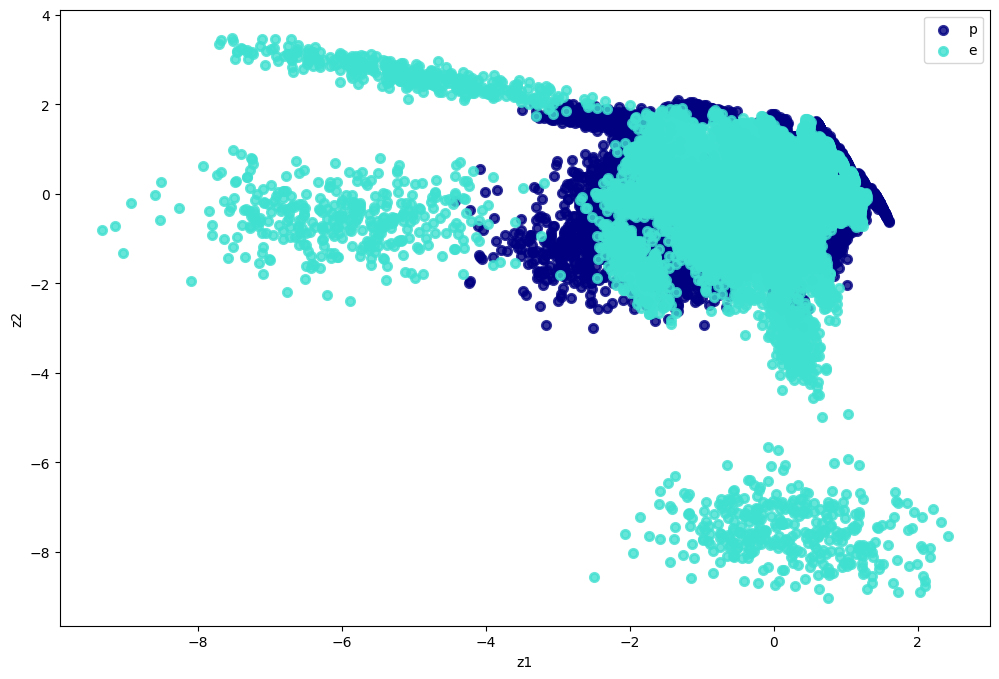

In [15]:
plt.figure(figsize=(12,8))
colors = ['navy', 'turquoise']
lw = 2
for color, i, target_name in zip(colors, [0, 1], vals):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )
plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

Нелинейные методы уменьшения размерности

Kernel PCA

In [ ]:
rbf_pca = KernelPCA(n_components=2, kernel='rbf', gamma=0.04)
X_new = rbf_pca.fit_transform(X)

In [ ]:
plt.figure(figsize=(12,8))
colors = ["navy", "turquoise"]
lw = 2

for color, i, target_name in zip(colors, [0, 1], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()

при компиляции возникает такая ошибка. Скорее всего из за того что датасет очень большой, а метод требует много ресурсов 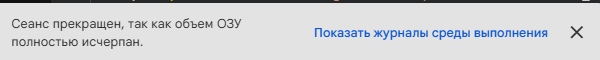

tSNE

In [16]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
X_new = tsne.fit_transform(X)

In [17]:
print('Initial Shape of X: ', X.shape)
print('New Shape of X: ', X_new.shape)
print('Kullback-Leibler divergence after optimization: ', tsne.kl_divergence_)
print('No. of iterations: ', tsne.n_iter_)

Initial Shape of X:  (61069, 5)
New Shape of X:  (61069, 2)
Kullback-Leibler divergence after optimization:  1.1713296175003052
No. of iterations:  999


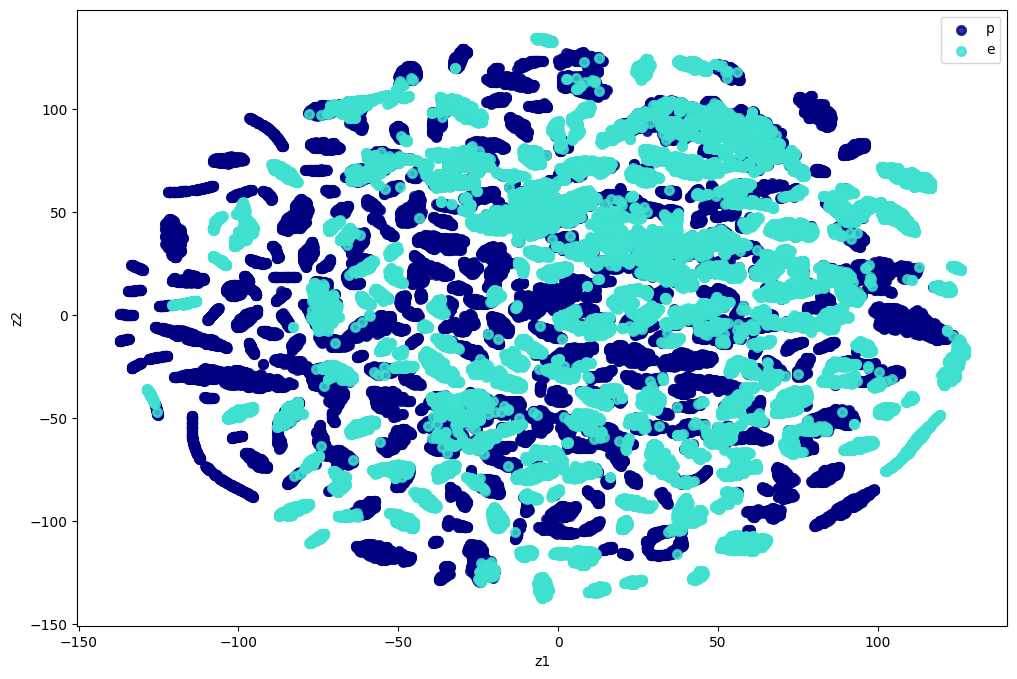

In [18]:
plt.figure(figsize=(12,8))
colors = ["navy", "turquoise"]
lw = 2

for color, i, target_name in zip(colors, [0, 1], cols_for_clusters):
    plt.scatter(
        X_new[y == i, 0], X_new[y == i, 1], color=color, alpha=0.8, lw=lw, label=vals[i]
    )

plt.legend(loc="best", shadow=False, scatterpoints=1)
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()